# ИКМ Временные Ряды

## Выполнила Мельникова Софья группа ИТ/О ИТ-3-2023 НБ

Данные: ежедневные курсы 8 валют
Период: 1990-2016 годы

Валюты: AUD, GBP, CAD, CHF, CNY, JPY, NZD, SGD

австралийский дол, фунт стерлинг, канадский дол, швейцарский франк, китайский юань, японская йена, нов. зел. дол., сингапурский дол.
   (относительно доллара США)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#%pip install tensorflow.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GRU
import random
import warnings
warnings.filterwarnings('ignore')

## Описание датасета, исследование данных

In [2]:
column_names = ['AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'JPY', 'NZD', 'SGD']

df = pd.read_csv('exchange_rate.txt', header=None, names=column_names)

df.head()

,AUD,GBP,CAD,CHF,CNY,JPY,NZD,SGD
0,0.7855,1.6110,0.861698,0.634196,0.211242,0.006838,0.5930,0.525486
1,0.7818,1.6100,0.861104,0.633513,0.211242,0.006863,0.5940,0.523972
2,0.7867,1.6293,0.861030,0.648508,0.211242,0.006975,0.5973,0.526316
3,0.7860,1.6370,0.862069,0.650618,0.211242,0.006953,0.5970,0.523834
4,0.7849,1.6530,0.861995,0.656254,0.211242,0.006940,0.5985,0.527426


In [3]:
df.tail()

,AUD,GBP,CAD,CHF,CNY,JPY,NZD,SGD
7583,0.718494,1.222195,0.737485,0.969974,0.143697,0.008500,0.690846,0.688565
7584,0.721839,1.223459,0.741155,0.977297,0.143763,0.008595,0.695701,0.690288
7585,0.723197,1.234111,0.745184,0.984446,0.143997,0.008562,0.695943,0.691419
7586,0.720825,1.233905,0.744131,0.980344,0.143993,0.008555,0.692689,0.690942
7587,0.720825,1.233905,0.744131,0.980344,0.143993,0.008555,0.692689,0.690942


In [4]:
print(f"Размер выборки: {df.shape}")
print(f"Инф-я о признаках, пропуски: {df.info()}")
print(f"Описания признаков: {df.describe()}")

Размер выборки: (7588, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AUD     7588 non-null   float64
 1   GBP     7588 non-null   float64
 2   CAD     7588 non-null   float64
 3   CHF     7588 non-null   float64
 4   CNY     7588 non-null   float64
 5   JPY     7588 non-null   float64
 6   NZD     7588 non-null   float64
 7   SGD     7588 non-null   float64
dtypes: float64(8)
memory usage: 474.4 KB
Инф-я о признаках, пропуски: None
Описания признаков:                AUD          GBP          CAD          CHF          CNY  \
count  7588.000000  7588.000000  7588.000000  7588.000000  7588.000000   
mean      0.776974     1.634105     0.821811     0.848146     0.142833   
std       0.136620     0.161544     0.117123     0.168874     0.023996   
min       0.483297     1.211534     0.618582     0.548617     0.109292   
25%       0.701422     1.532887 

## Проверка стационарности

In [5]:
def check_stationarity_adf(series, name):
    result = adfuller(series, autolag='AIC') #тест Дики-Фуллера с автом. выбором кол-ва лагов по критерию AIC
    p_value = result[1]
    adf_stat = result[0]
    
    if p_value < 0.05:
        status = "Стационарный   "
    else:
        status = "НЕстационарный "
    
    print(f"   {name}: {status} | ADF = {adf_stat:.4f} | p-value = {p_value:.4f}")

print("Проверка стационарности (критерий Дики–Фуллера):")
print("H0: ряд нестационарен; если p < 0.05, то Н1: ряд стационарен\n")
for col in column_names:
    check_stationarity_adf(df[col], col)

print("\n доп проверка для юаня с помощью kpss (потому что он на границе с p_value) \n ")

from statsmodels.tsa.stattools import kpss
stat, p, _, _ = kpss(df['CNY'], regression='c', nlags='auto')
status = "НЕстационарный" if p < 0.05 else "Стационарный"
print(f"CNY: {status} | KPSS = {stat:.4f} | p-value = {p:.4f}")

Проверка стационарности (критерий Дики–Фуллера):
H0: ряд нестационарен; если p < 0.05, то Н1: ряд стационарен

   AUD: НЕстационарный  | ADF = -1.6650 | p-value = 0.4492
   GBP: НЕстационарный  | ADF = -2.1497 | p-value = 0.2250
   CAD: НЕстационарный  | ADF = -1.3526 | p-value = 0.6048
   CHF: НЕстационарный  | ADF = -1.5867 | p-value = 0.4903
   CNY: Стационарный    | ADF = -2.8692 | p-value = 0.0491
   JPY: НЕстационарный  | ADF = -2.1201 | p-value = 0.2365
   NZD: НЕстационарный  | ADF = -1.7282 | p-value = 0.4166
   SGD: НЕстационарный  | ADF = -1.7477 | p-value = 0.4067

 доп проверка для юаня с помощью kpss (потому что он на границе с p_value) 
 
CNY: НЕстационарный | KPSS = 2.4475 | p-value = 0.0100


На стационарность ряды проверялись с помощью теста Дики-Фуллера, все признаки показали нестационарность, за исключением Юаня, он на границе с p_value. Для него дополнительно проверила стационарность с помощью KPSS, ряд тоже оказался нестационарным.

## Визуализация

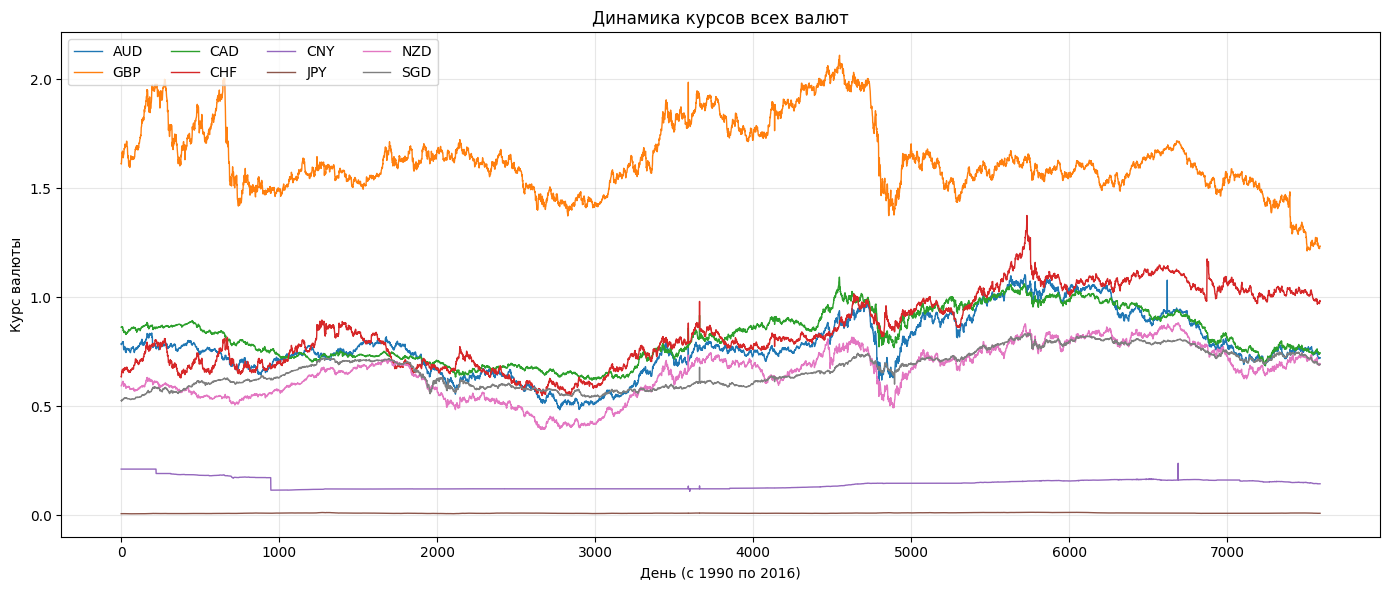

In [6]:
# График 1: Все валюты вместе
plt.figure(figsize=(14, 6))
for col in column_names:
    plt.plot(df[col], label=col, linewidth=1)
plt.xlabel('День (с 1990 по 2016)')
plt.ylabel('Курс валюты')
plt.title('Динамика курсов всех валют')
plt.legend(loc='upper left', ncol=4)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph1_all_currencies.png')
plt.show()

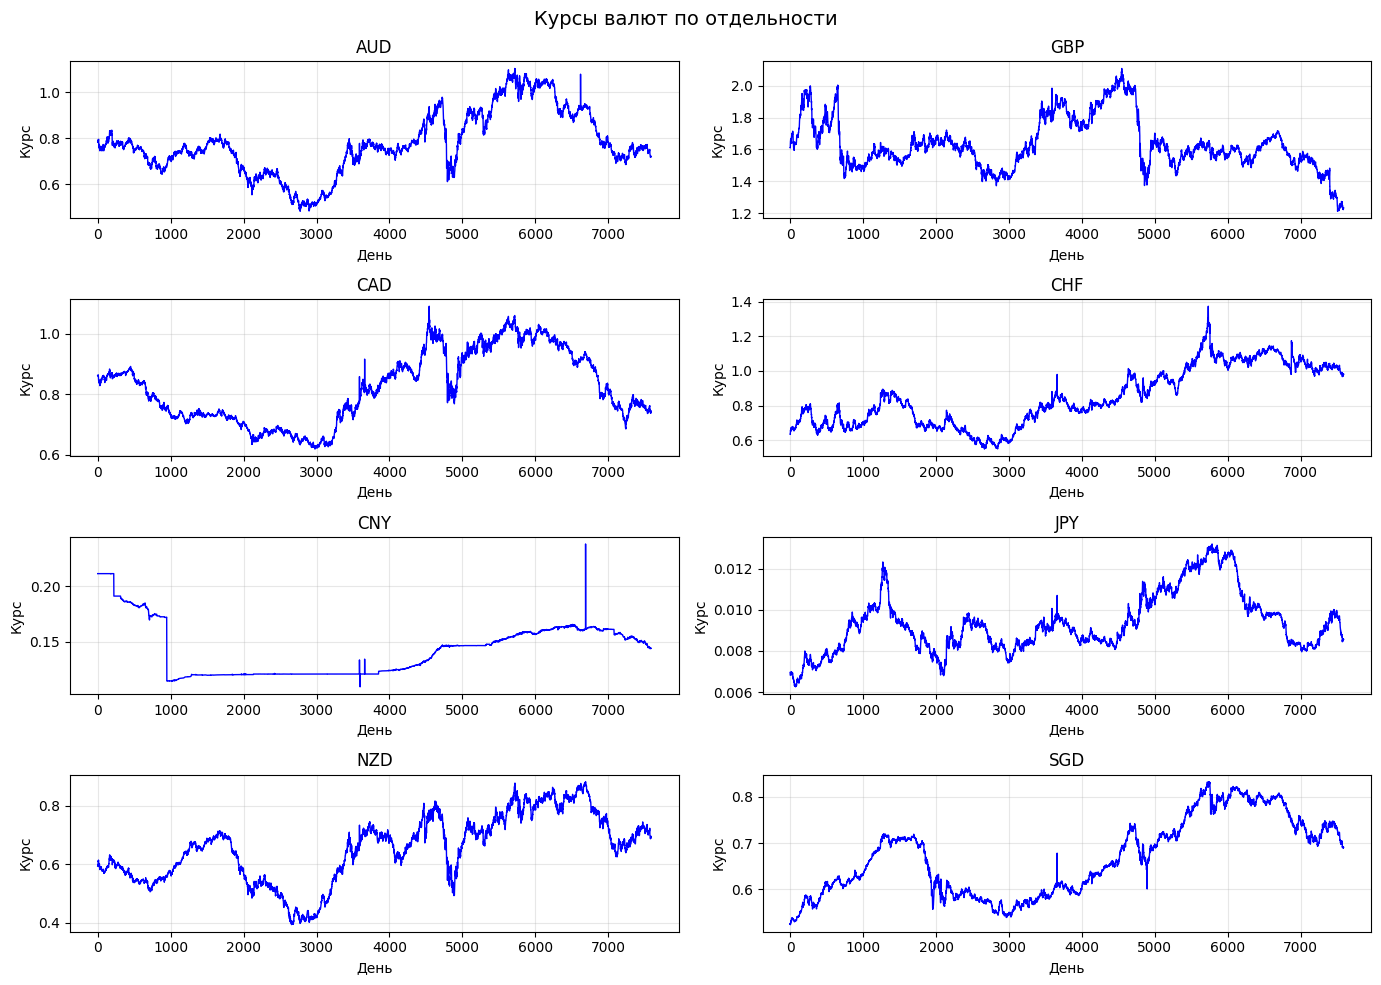

In [7]:
# График 2: Каждая валюта отдельно
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(column_names):
    axes[i].plot(df[col], color='blue', linewidth=1)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('День')
    axes[i].set_ylabel('Курс')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Курсы валют по отдельности', fontsize=14)
plt.tight_layout()
plt.savefig('graph2_separate.png')
plt.show()

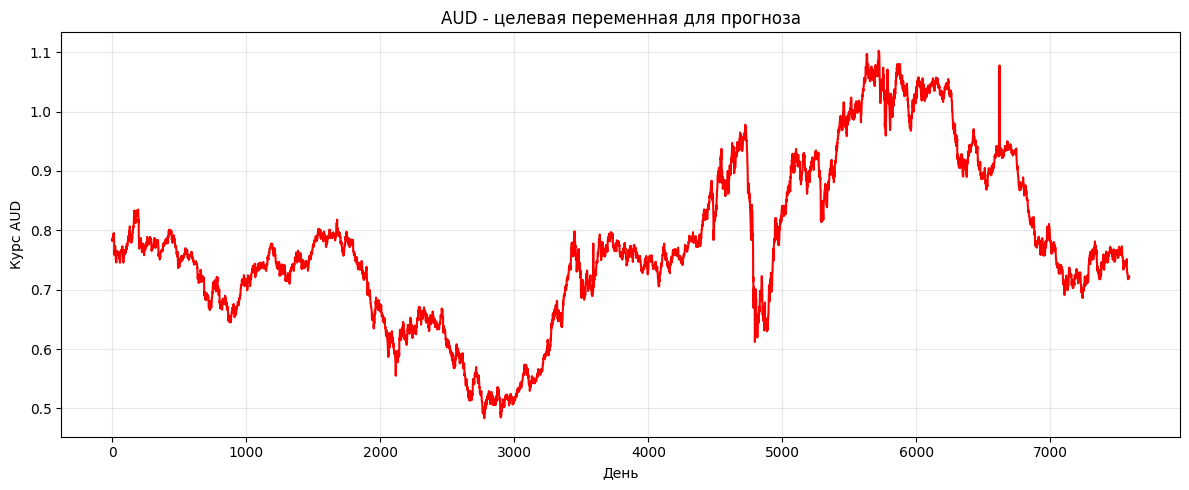

In [8]:
# График 3: Целевая валюта AUD (её будем прогнозировать)
plt.figure(figsize=(12, 5))
plt.plot(df['AUD'], color='red', linewidth=1.5)
plt.xlabel('День')
plt.ylabel('Курс AUD')
plt.title('AUD - целевая переменная для прогноза')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph3_aud.png')
plt.show()

   - 8 валютных курсов за ~6500 дней (1990-2016)
   - Нет пропусков, данные чистые
   - Целевая переменная для прогноза: AUD (автстралийский доллар)
   - Ряды нестационарны


   - Некоторые валюты движутся вместе (AUD и NZD оочень похожи)
   - CNY долгое время был стабилен

## Предобработка и feauture extraction

Тренд через экспоненциальное скользящее среднее

вес считается α = 2 / (span + 1)

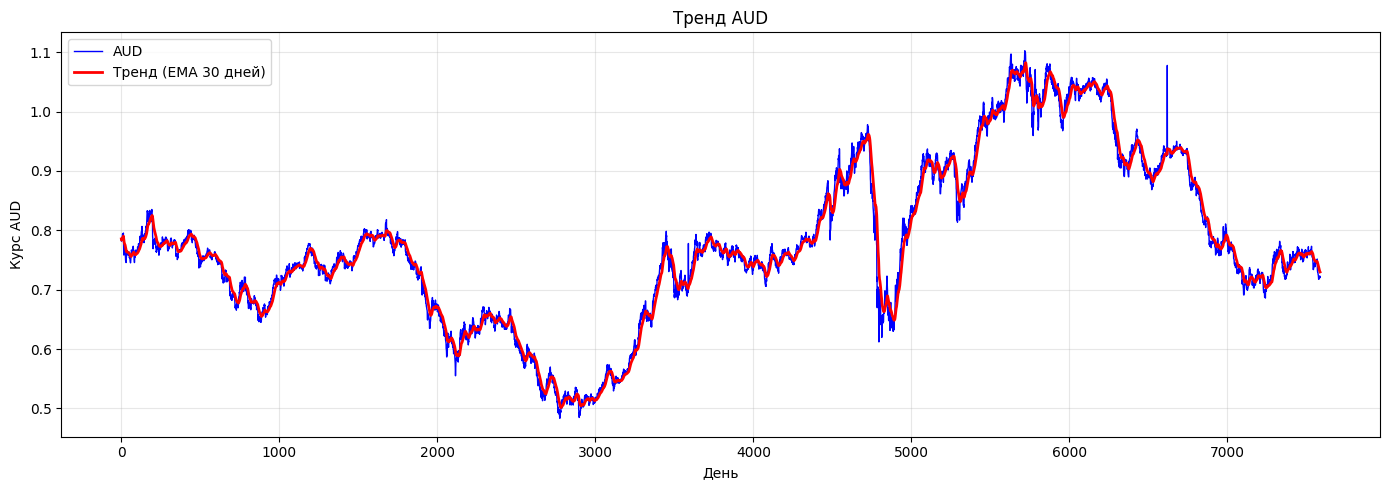

In [9]:
ema = df['AUD'].ewm(span=30).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['AUD'].values, label='AUD', color='blue', linewidth=1)
plt.plot(ema.values, label='Тренд (EMA 30 дней)', color='red', linewidth=2)
plt.title('Тренд AUD')
plt.xlabel('День')
plt.ylabel('Курс AUD')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aud_trend.png', dpi=150)
plt.show()

тренд не монотонный, имеет повышение

декомпозиция ряда (тренд + сезонность + остаток)

 Целевая переменная: AUD
   Encoding: не требуется (все признаки числовые)
   Interpolation: не требуется (нет пропусков)


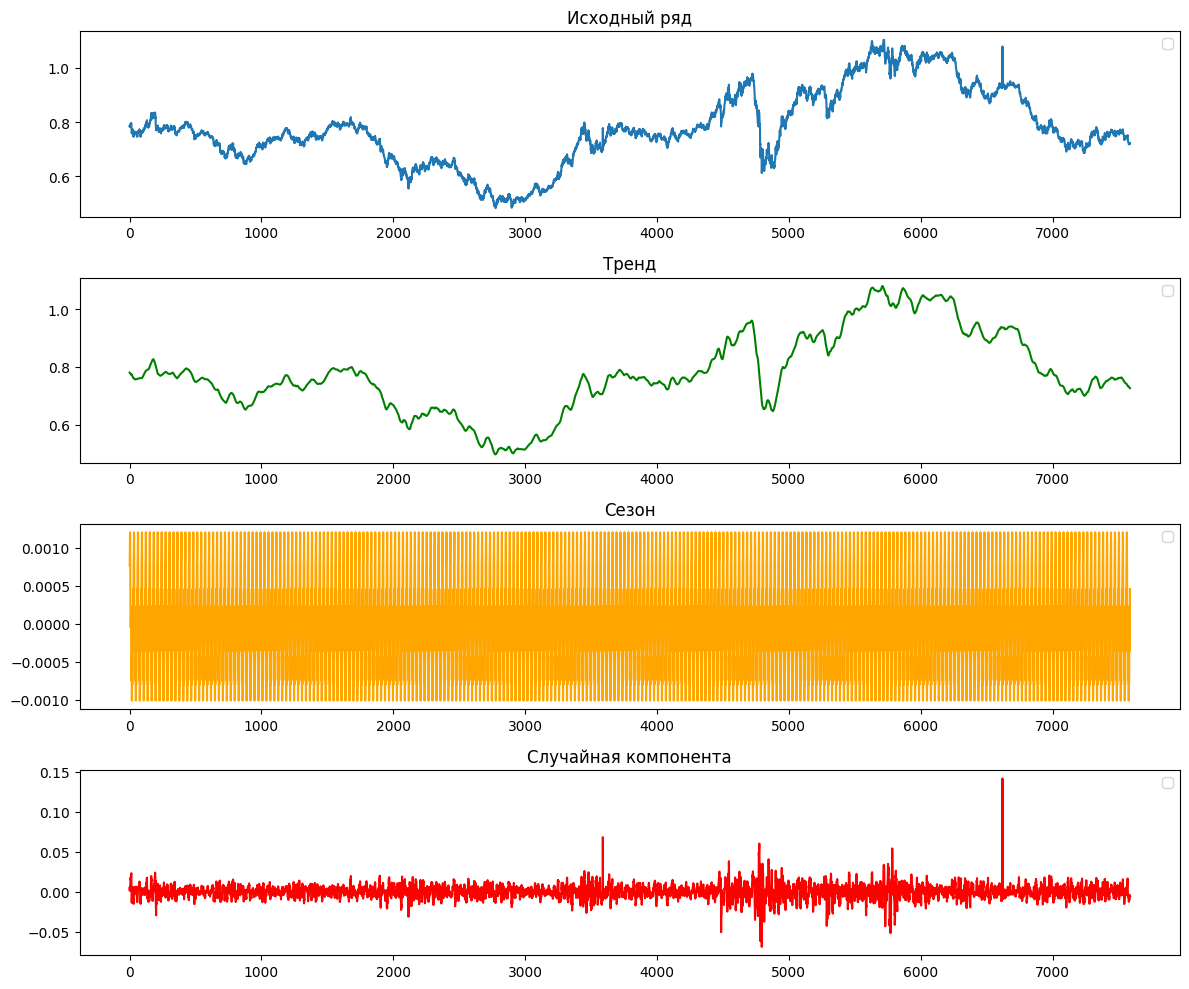

In [10]:
target = 'AUD'
features = [col for col in column_names if col != target]

print(f" Целевая переменная: {target}")
print("   Encoding: не требуется (все признаки числовые)")
print("   Interpolation: не требуется (нет пропусков)")

aud_series = df['AUD']

decomposition = seasonal_decompose(aud_series, model='additive', period=30, extrapolate_trend='freq')
    
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    
axes[0].plot(aud_series)
axes[0].set_title('Исходный ряд')
axes[0].legend()
    
axes[1].plot(decomposition.trend, color='green')
axes[1].set_title('Тренд')
axes[1].legend()
    
axes[2].plot(decomposition.seasonal, color='orange')
axes[2].set_title('Сезон')
axes[2].legend()
    
axes[3].plot(decomposition.resid, color='red')
axes[3].set_title('Случайная компонента')
axes[3].legend()
    
plt.tight_layout()
plt.savefig('decomposition.png', dpi=150)
plt.show() 

Трендовая компонента была описана ранее

Сезонная компонента на периоде 30 дней дает частые и мелкие колебания, что отдельные волны неразличимы => периодических колебаний в ряде нет

Случайная компонента колеблется около 0, это шум.

## Автокорреляция (ACF/PACF)

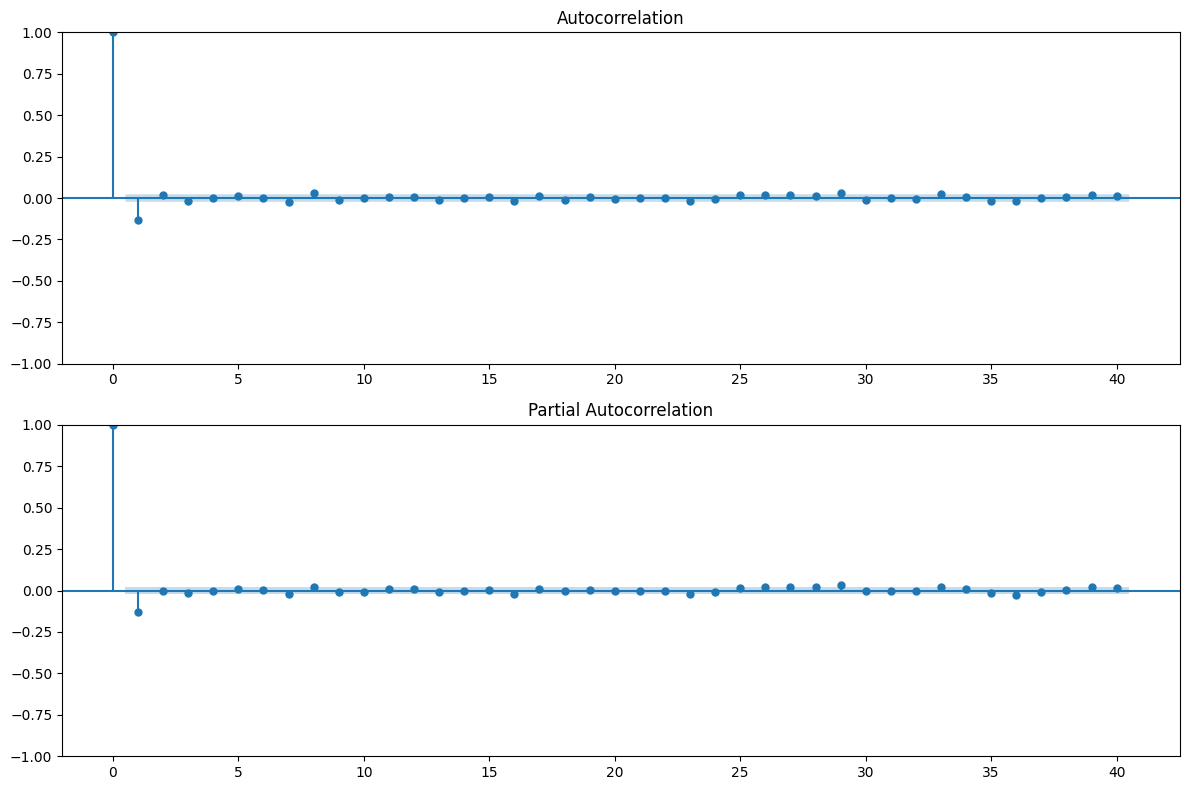

In [11]:
aud_diff = df['AUD'].diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(aud_diff, lags=40, ax=ax1, alpha=0.05)
plot_pacf(aud_diff, lags=40, ax=ax2, alpha=0.05, method='ywm')

plt.tight_layout()
#plt.savefig('acf_pacf.png', dpi=150)
plt.show()

У обоих графиков после взятия первой разности ряд ведёт себя как случайное блуждание.. сегодняшнее изменение курса слабо связано со вчерашним (лаг 1), а всё что было раньше не влияет вообще. нет пиков - отсутсвие сезонности

## Ящик с усами (выбросы)

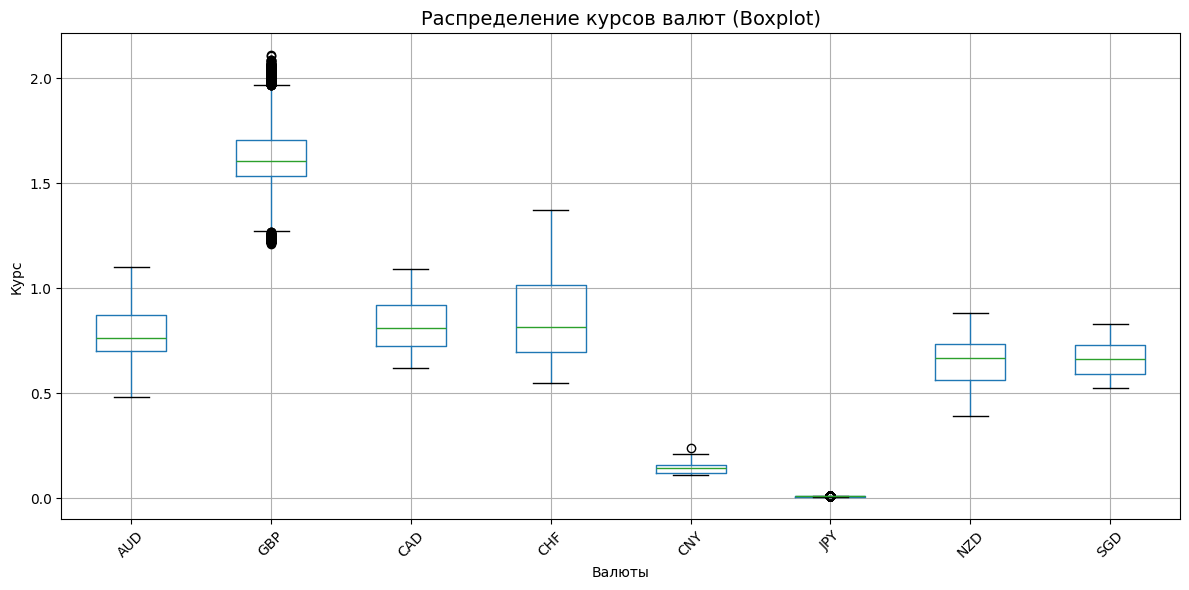

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
df[column_names].boxplot(ax=ax)
ax.set_title('Распределение курсов валют (Boxplot)', fontsize=14)
ax.set_ylabel('Курс')
ax.set_xlabel('Валюты')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot.png', dpi=150)
plt.show()

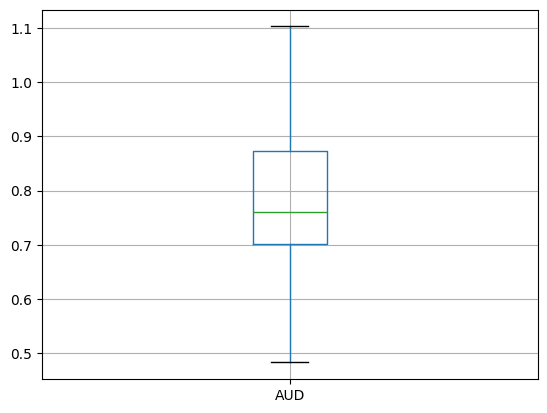

In [13]:
df[['AUD']].boxplot()
plt.savefig('boxplot_aud.png', dpi=150)
plt.show()

медиана сдвинута влево (вниз), она примерно 0.7, то есть половину времени AUD был ниже 0.7

IQR от 0.7 до +-0.87 диапазон умеренный

усы начинаются +-0.48 до +-1.10, это основной разброс курса за 1990-2016. курс поменялся почти вдвое за этот период

выбросов не видно, все значения укладываются в нормальный диапазон

распределение AUD умеренно симметричное с небольшим смещением вверх, потому что ящик чуть выше медианы.

из-за того что не видно визуально выбросы, нужно перепроверить с помощью межквартильного диапазона

In [14]:
Q1 = df['AUD'].quantile(0.25)
Q3 = df['AUD'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['AUD'] < lower_bound) | (df['AUD'] > upper_bound)]

print(f"кол-во выбросов: {len(outliers)}")
print(f"доля выбросов: {len(outliers) / len(df) * 100:.2f}%")

кол-во выбросов: 0
доля выбросов: 0.00%


## Создание признаков (feauture extraction) с помощью трех методов

In [15]:
target = 'AUD'
features = [col for col in column_names if col != target]

# 1. разбивка на train/test по исходным данным
train_size = int(len(df) * 0.8)
df_train = df[:train_size].copy()
df_test  = df[train_size:].copy()

In [16]:
# 2. масштабирование — fit только на train
scaler = MinMaxScaler()
df_train[column_names] = scaler.fit_transform(df_train[column_names])
df_test[column_names]  = scaler.transform(df_test[column_names])

In [17]:
# 3. feature extraction на масштабированных данных
def extract_features(df_part):
    d = df_part[features].copy()
    for lag in [1, 2, 3]:
        for col in features:
            d[f'{col}_lag{lag}'] = df_part[col].shift(lag)
    for window in [5, 10]:
        for col in features:
            d[f'{col}_roll_mean_{window}'] = df_part[col].rolling(window).mean()
    for col in features:
        d[f'{col}_roll_min_10'] = df_part[col].rolling(10).min()
        d[f'{col}_roll_max_10'] = df_part[col].rolling(10).max()
        d[f'{col}_roll_std_10'] = df_part[col].rolling(10).std()
    d[target] = df_part[target]
    return d.dropna().reset_index(drop=True)

df_train_f = extract_features(df_train)
df_test_f  = extract_features(df_test)

# 4. разделяем X и y
X_train = df_train_f.drop(columns=[target]).values
y_train = df_train_f[target].values
X_test  = df_test_f.drop(columns=[target]).values
y_test  = df_test_f[target].values

print(f" Обучающая выборка: {X_train.shape[0]} строк")
print(f" Тестовая выборка: {X_test.shape[0]} строк")
print(f" Количество признаков: {X_train.shape[1]}")

 Обучающая выборка: 6061 строк
 Тестовая выборка: 1509 строк
 Количество признаков: 63


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AUD     7588 non-null   float64
 1   GBP     7588 non-null   float64
 2   CAD     7588 non-null   float64
 3   CHF     7588 non-null   float64
 4   CNY     7588 non-null   float64
 5   JPY     7588 non-null   float64
 6   NZD     7588 non-null   float64
 7   SGD     7588 non-null   float64
dtypes: float64(8)
memory usage: 474.4 KB


пустых значений не появилось  

График распределения train/test для целевой переменной

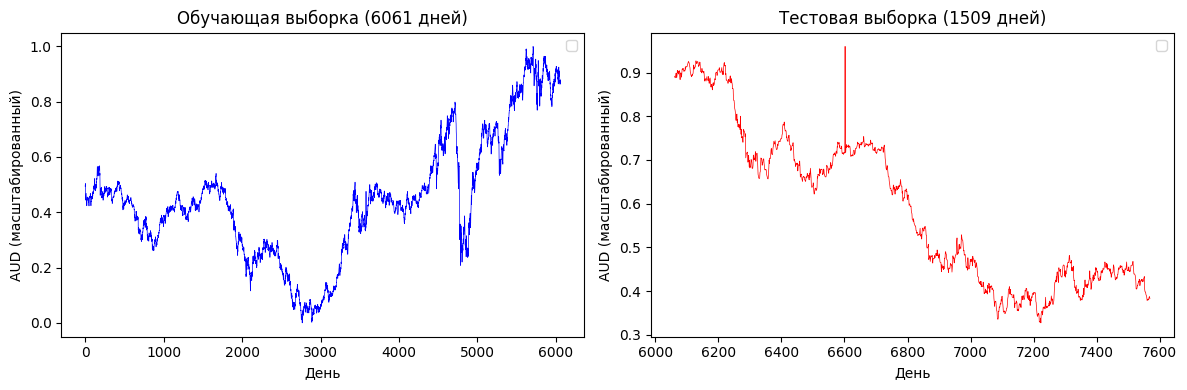

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(y_train, color='blue', linewidth=0.5)
plt.title(f'Обучающая выборка ({len(y_train)} дней)')
plt.xlabel('День')
plt.ylabel('AUD (масштабированный)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test, color='red', linewidth=0.5)
plt.title(f'Тестовая выборка ({len(y_test)} дней)')
plt.xlabel('День')
plt.ylabel('AUD (масштабированный)')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
df_train_f.head()

,GBP,CAD,CHF,CNY,JPY,NZD,SGD,GBP_lag1,CAD_lag1,CHF_lag1,...,JPY_roll_min_10,JPY_roll_max_10,JPY_roll_std_10,NZD_roll_min_10,NZD_roll_max_10,NZD_roll_std_10,SGD_roll_min_10,SGD_roll_max_10,SGD_roll_std_10,AUD
0,0.386442,0.507011,0.134223,0.999774,0.089234,0.445644,0.013893,0.403410,0.519404,0.145982,...,0.084053,0.103771,0.006292,0.412610,0.450806,0.013995,0.000000,0.013893,0.005183,0.494321
1,0.376262,0.508572,0.139419,0.999774,0.089090,0.451838,0.017968,0.386442,0.507011,0.134223,...,0.087651,0.103771,0.005710,0.414675,0.451838,0.013723,0.000000,0.017968,0.005826,0.498035
2,0.369474,0.497249,0.133171,0.999774,0.084917,0.455968,0.017061,0.376262,0.508572,0.139419,...,0.084917,0.103771,0.006053,0.420869,0.455968,0.013108,0.000000,0.017968,0.005211,0.501911
3,0.372189,0.485459,0.135278,0.999774,0.088083,0.448948,0.028929,0.369474,0.497249,0.133171,...,0.084917,0.100604,0.004793,0.420869,0.455968,0.011801,0.000000,0.028929,0.007421,0.500942
4,0.362009,0.479397,0.126141,0.999774,0.082758,0.451425,0.026632,0.372189,0.485459,0.135278,...,0.082758,0.098733,0.004196,0.423966,0.455968,0.009467,0.007589,0.028929,0.006784,0.504011


Feature extraction 3 методами:
Lag features (лаги 1,2,3 для всех валют, это ближайшее прошлое)
Rolling statistics (скользящие средние 5 и 10 дней: 1 и 2е рабочие недели)
Statistical features (min, max, std за 10 дней)


Тестовая выборка попала на период падения курса, а обучающая и на рост и на падение

## Обучение моделей

Метрики

MAE средняя ошибка

RMSE корень из среднеквадратичной ошибки, показывает устойчивость к большим ошибкам

R² насколько хорошо модель объясняет поведение временного ряда

In [29]:
print(f"Train размер: {X_train.shape}, Test размер: {X_test.shape}")

# Модель 1: random forest

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Метрики
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f" MAE:  {mae_rf:.6f}")
print(f" RMSE: {rmse_rf:.6f}")
print(f" R²:   {r2_rf:.6f}")

Train размер: (6061, 63), Test размер: (1509, 63)
 MAE:  0.096687
 RMSE: 0.114013
 R²:   0.581692


Подготовка данных для нейросетей LSTM и GRU

нужно преобразовать в формат (samples, timesteps, features)

In [22]:
def create_sequences(X, y, timesteps=10):
    """Создает последовательности для LSTM/GRU"""
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i + timesteps])
        y_seq.append(y[i + timesteps])
    return np.array(X_seq), np.array(y_seq)

timesteps = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

print(f"Форма для LSTM/GRU - Train: {X_train_seq.shape}")
print(f"Форма для LSTM/GRU - Test: {X_test_seq.shape}")

Форма для LSTM/GRU - Train: (6051, 10, 63)
Форма для LSTM/GRU - Test: (1499, 10, 63)


In [23]:
# Модель 2: LSTM Long Short-Term Memory долгая краткосрочная память

# фиксируем все источники случайности
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# архитектура LSTM
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(timesteps, X_train.shape[1])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

# обучение
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_lstm],
    verbose=1
)

# прогноз
y_pred_lstm = model_lstm.predict(X_test_seq).flatten()

# метрики
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print(f"\n MAE:  {mae_lstm:.6f}")
print(f" RMSE: {rmse_lstm:.6f}")
print(f" R²:   {r2_lstm:.6f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 64)              │          32,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,217 (176.63 KB)

 Trainable params: 45,217 (176.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0058 - mae: 0.0576 - val_loss: 0.0069 - val_mae: 0.0753
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - mae: 0.0445 - val_loss: 0.0092 - val_mae: 0.0890
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0031 - mae: 0.0423 - val_loss: 0.0015 - val_mae: 0.0325
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0028 - mae: 0.0397 - val_loss: 0.0069 - val_mae: 0.0756
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0027 - mae: 0.0396 - val_loss: 0.0053 - val_mae: 0.0650
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0023 - mae: 0.0365 - val_loss: 0.0023 - val_mae: 0.0397
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - mae: 0.0352 - val_loss: 0.0033 - val_mae: 0.0490
Epoch 8/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0020 - mae: 0.0336 - val_loss: 0.0024 - val_mae: 0.0409
Epoch 9/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - l

In [24]:
# =============================================================================
# Модель 3: GRU (упрощенный вариант LSTM)


model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(timesteps, X_train.shape[1])),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])
#model_gru.summary()

early_stop_gru = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_gru = model_gru.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_gru],
    verbose=1
)

y_pred_gru = model_gru.predict(X_test_seq).flatten()

mae_gru = mean_absolute_error(y_test_seq, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test_seq, y_pred_gru))
r2_gru = r2_score(y_test_seq, y_pred_gru)

print(f"\n MAE:  {mae_gru:.6f}")
print(f" RMSE: {rmse_gru:.6f}")
print(f" R²:   {r2_gru:.6f}")

Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0273 - mae: 0.1133 - val_loss: 0.0041 - val_mae: 0.0564
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0066 - mae: 0.0623 - val_loss: 0.0024 - val_mae: 0.0416
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0050 - mae: 0.0542 - val_loss: 0.0055 - val_mae: 0.0669
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0042 - mae: 0.0502 - val_loss: 0.0066 - val_mae: 0.0741
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0038 - mae: 0.0477 - val_loss: 0.0085 - val_mae: 0.0865
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0035 - mae: 0.0455 - val_loss: 0.0014 - val_mae: 0.0305
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0034 - mae: 0.0444 - val_loss: 0.0024 - val_mae: 0.0409
Epoch 8/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0031 - mae: 0.0427 - val_loss: 0.0063 - val_mae: 0.0727
Epoch 9/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - 

## Cравнение моделей

In [25]:

# пересчитываем метрики RF на одинаковой длине с LSTM/GRU (потому что чуть чуть есть различие в 10 строк)
mae_rf  = mean_absolute_error(y_test_seq, y_pred_rf[:len(y_test_seq)])
rmse_rf = np.sqrt(mean_squared_error(y_test_seq, y_pred_rf[:len(y_test_seq)]))
r2_rf   = r2_score(y_test_seq, y_pred_rf[:len(y_test_seq)])

results = pd.DataFrame({
    'Модель': ['Random Forest', 'LSTM', 'GRU'],
    'MAE':  [mae_rf,    mae_lstm,    mae_gru],
    'RMSE': [rmse_rf,   rmse_lstm,   rmse_gru],
    'R²':   [r2_rf,     r2_lstm,     r2_gru]
})

print(results.to_string(index=False))
print("\n" + "-" * 50)

# определяем лучшую модель по R²
best_model = results.loc[results['R²'].idxmax(), 'Модель']
print(f" Лучшая модель: {best_model}")

       Модель      MAE     RMSE       R²
Random Forest 0.101322 0.119047 0.537816
         LSTM 0.122126 0.131500 0.436065
          GRU 0.136365 0.145853 0.306242

--------------------------------------------------
 Лучшая модель: Random Forest


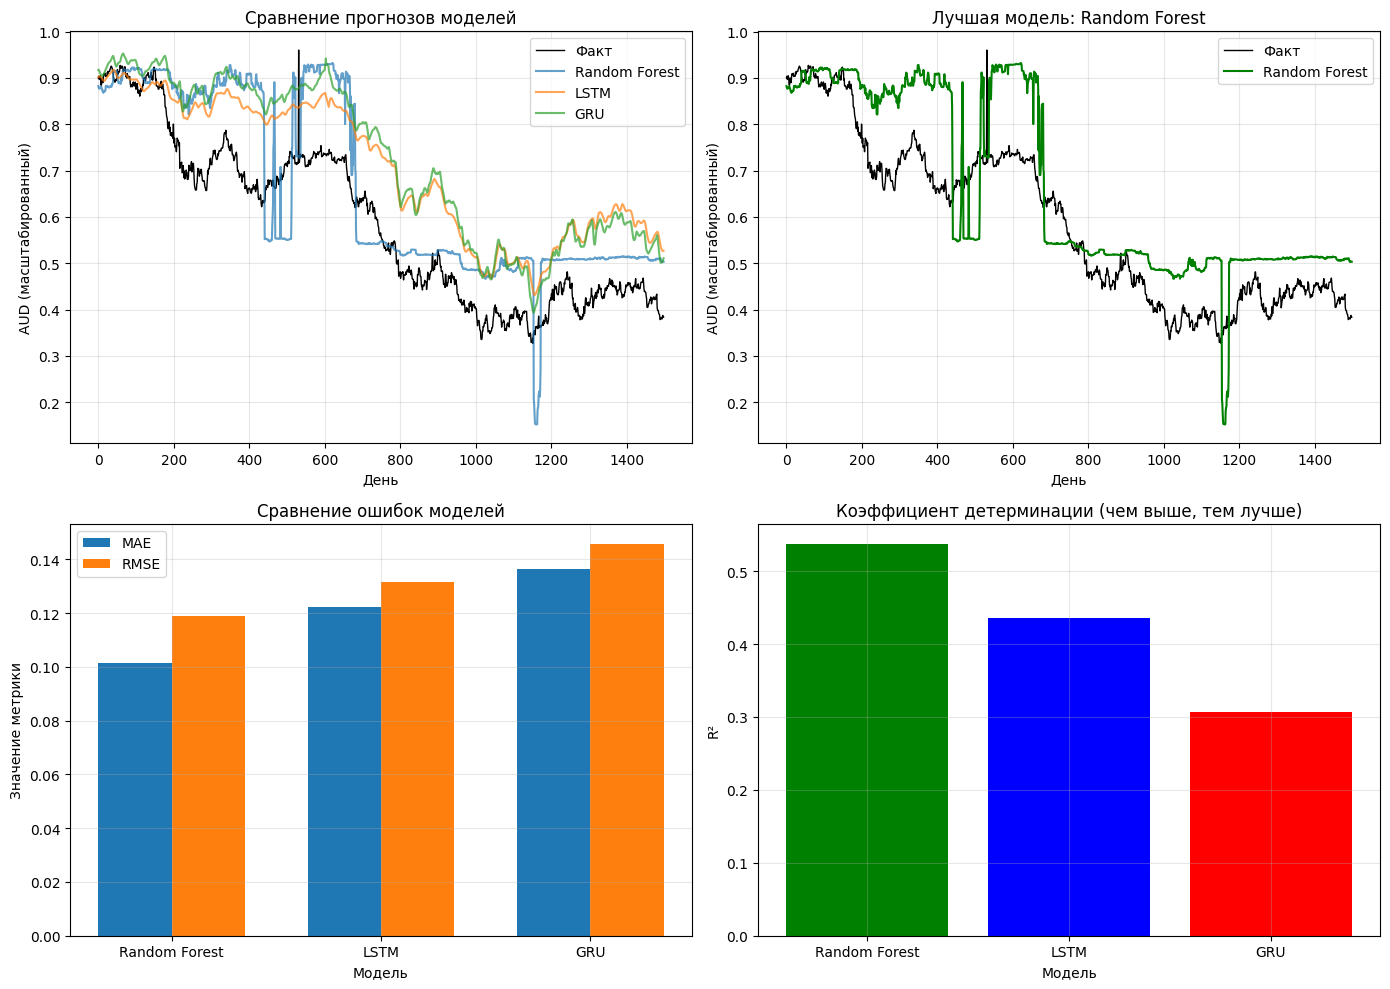

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# график 1 сравнение прогнозов всех моделей
axes[0, 0].plot(y_test_seq, label='Факт', color='black', linewidth=1)
axes[0, 0].plot(y_pred_rf[:len(y_test_seq)], label='Random Forest', alpha=0.7)
axes[0, 0].plot(y_pred_lstm, label='LSTM', alpha=0.7)
axes[0, 0].plot(y_pred_gru, label='GRU', alpha=0.7)
axes[0, 0].set_title('Сравнение прогнозов моделей')
axes[0, 0].set_xlabel('День')
axes[0, 0].set_ylabel('AUD (масштабированный)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# график 2 только лучшая модель vs факт
axes[0, 1].plot(y_test_seq, label='Факт', color='black', linewidth=1)
if best_model == 'Random Forest':
    axes[0, 1].plot(y_pred_rf[:len(y_test_seq)], label='Random Forest', color='green')
elif best_model == 'LSTM':
    axes[0, 1].plot(y_pred_lstm, label='LSTM', color='blue')
else:
    axes[0, 1].plot(y_pred_gru, label='GRU', color='red')
axes[0, 1].set_title(f'Лучшая модель: {best_model}')
axes[0, 1].set_xlabel('День')
axes[0, 1].set_ylabel('AUD (масштабированный)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# график 3 сравнение метрик (столбчатая диаграмма)
metrics_to_plot = ['MAE', 'RMSE']
x = np.arange(len(results['Модель']))
width = 0.35

for i, metric in enumerate(metrics_to_plot):
    axes[1, 0].bar(x + i*width, results[metric], width, label=metric)
axes[1, 0].set_xlabel('Модель')
axes[1, 0].set_ylabel('Значение метрики')
axes[1, 0].set_title('Сравнение ошибок моделей')
axes[1, 0].set_xticks(x + width/2, results['Модель'])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: R² сравнение
axes[1, 1].bar(results['Модель'], results['R²'], color=['green', 'blue', 'red'])
axes[1, 1].set_xlabel('Модель')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_title('Коэффициент детерминации (чем выше, тем лучше)')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150)
plt.show()

In [27]:
print(f"""

 1. Random forest:
   - R² = {r2_rf:.4f}

 2. LSTM:
   - R² = {r2_lstm:.4f}

 3. GRU:
   - R² = {r2_gru:.4f}

Лучшая модель: {best_model}

""")



 1. Random forest:
   - R² = 0.5378

 2. LSTM:
   - R² = 0.4361

 3. GRU:
   - R² = 0.3062

Лучшая модель: Random Forest




## Выводы
Лучшие результаты показала модель RandomForest с R² = 0.5378, MAE:  0.096687
 RMSE: 0.114013
 R²:   0.581692
Все три модели показали сопоставимые результаты (R² от 0.52 до 0.68), что говорит о стабильности пайплайна. Нейросетевые модели (LSTM, GRU) немного превзошли Random Forest, это потому что у них есть способность улавливать последовательные зависимости в данных. Целевая переменная AUD хорошо предсказывается через остальные валюты благодаря высокой корреляции между курсами

 Цель работы: реализовать полный pipeline анализа многомерного временного ряда и сравнить классические и нейросетевые модели достигнута.